#### Install Packages and Import Data
To set up the environment, run the following two cells. Setting everything up may take a few moments.

Do not alter any of the code in the next two cells.

In [51]:
%%capture
################################
#### do not alter this code ####
################################

!pip install pandas
!pip install jupysql
!pip install matplotlib
!pip install click
!pip install seaborn


In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np
import seaborn as sns

In [4]:
%%capture

################################
#### do not alter this code ####
################################

ad_channel_path="data/ad_channels.csv"
clicks_path="data/clicks.csv"
locks_path="data/locks.csv"
sales_path="data/sales.csv"
spend_path="data/spend.csv"
vehicle_path="data/vehicles.csv"

ad_channels=pd.read_csv(ad_channel_path)
clicks=pd.read_csv(clicks_path)
locks=pd.read_csv(locks_path)
sales=pd.read_csv(sales_path)
spend=pd.read_csv(spend_path)
vehicles=pd.read_csv(vehicle_path)

%load_ext sql
%sql sqlite://

%sql --persist ad_channels
%sql --persist clicks
%sql --persist locks
%sql --persist sales
%sql --persist spend
%sql --persist vehicles

______________________________________________________
______________________________________________________


In [5]:
ad_channels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   channel_id  16 non-null     int64 
 1   channel     16 non-null     object
dtypes: int64(1), object(1)
memory usage: 388.0+ bytes


In [6]:
clicks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168907 entries, 0 to 168906
Data columns (total 3 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   click_datetime  168907 non-null  object
 1   channel_id      168907 non-null  int64 
 2   user_id         168907 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 3.9+ MB


In [7]:
locks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13991 entries, 0 to 13990
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   lock_id        13991 non-null  int64 
 1   user_id        13991 non-null  int64 
 2   lock_datetime  13991 non-null  object
dtypes: int64(2), object(1)
memory usage: 328.0+ KB


In [8]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1348 entries, 0 to 1347
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            1335 non-null   float64
 1   lock_id            1348 non-null   int64  
 2   sale_datetime      1348 non-null   object 
 3   sale_id            1348 non-null   int64  
 4   make               1348 non-null   object 
 5   model              1348 non-null   object 
 6   has_trade_in       1348 non-null   int64  
 7   is_financed        1348 non-null   int64  
 8   apr                417 non-null    float64
 9   delivery_distance  1348 non-null   int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 105.4+ KB


In [9]:
spend.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3424 entries, 0 to 3423
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   channel_id  3424 non-null   int64  
 1   date        3424 non-null   object 
 2   spend       3424 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 80.4+ KB


In [10]:
vehicles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   make        40 non-null     object 
 1   model       40 non-null     object 
 2   bodystyle   40 non-null     object 
 3   avg_margin  40 non-null     float64
dtypes: float64(1), object(3)
memory usage: 1.4+ KB


In [11]:
ad_channels.head()

,channel_id,channel
0,1,Search Engine-Hooli_Convertible
1,2,Search Engine-Hooli_Sedan
2,3,Search Engine-Hooli_Truck
3,4,Search Engine-Bam_Convertible
4,5,Search Engine-Bam_Sedan


In [12]:
# creating columns - (category, partner, campaign) from channel column
ad_channels['channel'] = ad_channels['channel'].astype(str)
ad_channels[['category', 'partner_campaign']] = ad_channels['channel'].str.split('-',n=1, expand = True)

In [13]:
ad_channels[['partner', 'campaign']] = ad_channels['partner_campaign'].str.split('_',n=1, expand = True)

In [14]:
ad_channels.head()

,channel_id,channel,category,partner_campaign,partner,campaign
0,1,Search Engine-Hooli_Convertible,Search Engine,Hooli_Convertible,Hooli,Convertible
1,2,Search Engine-Hooli_Sedan,Search Engine,Hooli_Sedan,Hooli,Sedan
2,3,Search Engine-Hooli_Truck,Search Engine,Hooli_Truck,Hooli,Truck
3,4,Search Engine-Bam_Convertible,Search Engine,Bam_Convertible,Bam,Convertible
4,5,Search Engine-Bam_Sedan,Search Engine,Bam_Sedan,Bam,Sedan


In [15]:
# removing columns

ad_channels = ad_channels.drop(columns = ['partner_campaign'])

In [16]:
clicks.head()

,click_datetime,channel_id,user_id
0,2022-08-16 22:40:45.354986,9,18878402
1,2022-08-12 09:44:06.717217,3,37693359
2,2022-11-20 07:44:40.178093,15,95101706
3,2022-11-08 20:29:41.890408,14,90468324
4,2022-07-17 19:50:32.656824,8,73921344


In [17]:
spend.head()

,channel_id,date,spend
0,1,2022-06-01,134.07
1,1,2022-06-02,45.11
2,1,2022-06-03,66.23
3,1,2022-06-04,28.03
4,1,2022-06-05,33.95


#### Q1. channel with lowest cost per click

In [18]:
# Which channel has lowest cost per click
# cost per click: amount spend over each click
# cpc = total spend/total clicks
# dataframes to use: ad_channels, clicks, spend

# total clicks per channel
clicks_per_channel = clicks.groupby('channel_id')['user_id'].count().reset_index(name = 'total_clicks')
# clicks_per_channel.head()

# total spend per channel
spend_per_channel = spend.groupby('channel_id')['spend'].sum().reset_index(name = 'total_spend($)')
# spend_per_channel.head()

# combining clicks and spend data per channel
clicks_spend_data = clicks_per_channel.merge(spend_per_channel, on = 'channel_id').merge(ad_channels, on = 'channel_id')
# clicks_spend_data.head()

# calculating cost per click = spend/ total clicks
clicks_spend_data['cost_per_click(cpc)'] = clicks_spend_data['total_spend($)']/clicks_spend_data['total_clicks']

# return category index with lowest cost per acquisition
lowest_cpc_category = clicks_spend_data.groupby('category')['cost_per_click(cpc)'].mean().idxmin()
print(f"Category with lowest CPC: {lowest_cpc_category}")



Category with lowest CPC: Social Media


#### Q2. top three campaigns in terms of number of sales generated by first touch attribution

In [19]:
clicks.head()

,click_datetime,channel_id,user_id
0,2022-08-16 22:40:45.354986,9,18878402
1,2022-08-12 09:44:06.717217,3,37693359
2,2022-11-20 07:44:40.178093,15,95101706
3,2022-11-08 20:29:41.890408,14,90468324
4,2022-07-17 19:50:32.656824,8,73921344


In [20]:
# first touch attribution: 
# 1. Need to identify the first touch for each customer (by earliest click_datetime)
# dataframes: sales, clicks

clicks['click_datetime'] = pd.to_datetime(clicks['click_datetime'])
first_touch = clicks.sort_values(by = 'click_datetime').groupby('user_id').first().reset_index().rename(columns = {'click_datetime':'firsttouch_date'})


In [21]:
sales.head()

,user_id,lock_id,sale_datetime,sale_id,make,model,has_trade_in,is_financed,apr,delivery_distance
0,27416583.0,23163572,9/14/2022 20:13,1591322,Honda,Civic,1,0,NaN,719
1,11528490.0,24043656,9/27/2022 21:28,1592709,Toyota,Tacoma,0,1,0.131,388
2,28075930.0,24380774,9/20/2022 20:14,1592345,Jeep,Wrangler,0,0,NaN,350
3,28563986.0,24486868,9/15/2022 19:31,1592059,Mercedes-Benz,GLC,0,0,NaN,1057
4,28591774.0,24520951,9/11/2022 21:53,1591860,Mercedes-Benz,GLC,1,0,NaN,184


In [22]:

sales['sale_datetime'] = pd.to_datetime(sales['sale_datetime'])

# combining firsttouch info for each user with respective sales information and adding channel name
firsttouch_sales_data = first_touch.merge(sales, on = 'user_id').merge(ad_channels, on = 'channel_id')

# identifying top campaigns by number of sales
top_campaigns = (
    firsttouch_sales_data
    .groupby('campaign')['sale_id']
    .count()
    .reset_index(name = 'total_number_of_sales')
    .sort_values(by = 'total_number_of_sales', ascending = False)
    .head(3)
)

print(top_campaigns)

      campaign  total_number_of_sales
2        Sedan                    265
1  Convertible                    187
0          25+                    175


In [23]:
firsttouch_sales_data.head()

,user_id,firsttouch_date,channel_id,lock_id,sale_datetime,sale_id,make,model,has_trade_in,is_financed,apr,delivery_distance,channel,category,partner,campaign
0,38769,2022-09-18 00:05:08,5,26334269,2022-10-29 00:16:00,1624686,Subaru,Forester,0,0,NaN,659,Search Engine-Bam_Sedan,Search Engine,Bam,Sedan
1,99994,2022-10-16 08:55:37,10,26423056,2022-11-11 13:11:00,1641936,Land Rover,Range Rover,0,0,NaN,631,Online Video-WeTube_25+,Online Video,WeTube,25+
2,112497,2022-08-27 21:52:59,15,26120673,2022-11-03 14:33:00,1628000,Ford,Mustang,0,0,NaN,941,Third Party Listing-RealTruck,Third Party Listing,RealTruck,None
3,135937,2022-10-19 04:23:17,6,27526924,2022-12-22 21:26:00,1683483,Chevrolet,Silverado,0,0,NaN,517,Search Engine-Bam_Truck,Search Engine,Bam,Truck
4,139005,2022-10-09 13:51:43,2,26274535,2022-10-26 22:55:00,1624760,Chevrolet,Malibu,0,0,NaN,1171,Search Engine-Hooli_Sedan,Search Engine,Hooli,Sedan


#### Q3. Campaigns with most MoM decline in number of sales generated from Oct to Dec

In [24]:
firsttouch_sales_data['sale_month'] = firsttouch_sales_data['sale_datetime'].dt.to_period('M')


In [25]:
firsttouch_sales_data.head()

,user_id,firsttouch_date,channel_id,lock_id,sale_datetime,sale_id,make,model,has_trade_in,is_financed,apr,delivery_distance,channel,category,partner,campaign,sale_month
0,38769,2022-09-18 00:05:08,5,26334269,2022-10-29 00:16:00,1624686,Subaru,Forester,0,0,NaN,659,Search Engine-Bam_Sedan,Search Engine,Bam,Sedan,2022-10
1,99994,2022-10-16 08:55:37,10,26423056,2022-11-11 13:11:00,1641936,Land Rover,Range Rover,0,0,NaN,631,Online Video-WeTube_25+,Online Video,WeTube,25+,2022-11
2,112497,2022-08-27 21:52:59,15,26120673,2022-11-03 14:33:00,1628000,Ford,Mustang,0,0,NaN,941,Third Party Listing-RealTruck,Third Party Listing,RealTruck,None,2022-11
3,135937,2022-10-19 04:23:17,6,27526924,2022-12-22 21:26:00,1683483,Chevrolet,Silverado,0,0,NaN,517,Search Engine-Bam_Truck,Search Engine,Bam,Truck,2022-12
4,139005,2022-10-09 13:51:43,2,26274535,2022-10-26 22:55:00,1624760,Chevrolet,Malibu,0,0,NaN,1171,Search Engine-Hooli_Sedan,Search Engine,Hooli,Sedan,2022-10


In [26]:
# filtering data within Oct and Dec months
oct_dec_sales = firsttouch_sales_data[(firsttouch_sales_data['sale_month'] > '2022-10') & (firsttouch_sales_data['sale_month'] <= '2022-12')]

# group sales by month and campaign over number of sales transactions
monthly_sales_by_campaign = oct_dec_sales.groupby(['campaign','sale_month'])['sale_id'].count().unstack()

#calculated sales growth in percentage values
monthly_sales_by_campaign['sales_growth'] = monthly_sales_by_campaign.pct_change(axis = 'columns').iloc[:,-1]

top_growth_campaigns = monthly_sales_by_campaign.sort_values(by = 'sales_growth', ascending = False).head(3)
top_decline_campaigns = monthly_sales_by_campaign.sort_values(by = 'sales_growth').head(3)

print("Campaign with most growth: ") 
print(top_growth_campaigns)
print("\n Campaign with most decline: ") 
print(top_decline_campaigns)

Campaign with most growth: 
sale_month  2022-11  2022-12  sales_growth
campaign                                  
Truck            24       38      0.583333
25+              36       55      0.527778
Sedan            27       38      0.407407

 Campaign with most decline: 
sale_month   2022-11  2022-12  sales_growth
campaign                                   
Convertible       28       34      0.214286
Sedan             27       38      0.407407
25+               36       55      0.527778


In [27]:
ad_channels['campaign'].unique()

array(['Convertible', 'Sedan', 'Truck', 'Teen', '25+', None], dtype=object)

### Q4. Partner with lost CAC

In [28]:
# calculating customer acquisition cost by partner


# total sales transactions by partner
sales_by_partner = firsttouch_sales_data.groupby('partner')['sale_id'].count().reset_index()

# total spend by partner
spend_per_partner = clicks_spend_data.groupby('partner')['total_spend($)'].sum().reset_index()

# combining sales and spend data by partner
customer_acquisition_cost = spend_per_partner.merge(sales_by_partner, on = 'partner')

# CAC: spend/ Number of sales
customer_acquisition_cost['CAC($)'] = customer_acquisition_cost['total_spend($)']/customer_acquisition_cost['sale_id']

# least customer acquisition cost oriented partner
most_cost_efficient_partner = customer_acquisition_cost.loc[customer_acquisition_cost['CAC($)'].idxmin(), 'partner']

print(most_cost_efficient_partner)

Debit Dharma


In [29]:
ad_channels['partner'].unique()

array(['Hooli', 'Bam', 'Datankle', 'WeTube', 'Debit Dharma',
       'Giving Vine', 'KnickKnack', 'HeadLedger', 'RealTruck',
       'ManualBarter'], dtype=object)

#### Q5. Channel with best ROI and the worst!

In [30]:
#### Calculating the APR modifier: average monthly APR for financed sales
# specific to financed sales transactions

financed_sales = firsttouch_sales_data[firsttouch_sales_data['is_financed'] == 1]

# monthly average apr
avg_monthly_apr = financed_sales.groupby('sale_month')['apr'].mean().reset_index(name = 'avg_apr')
avg_monthly_apr.head()



,sale_month,avg_apr
0,2022-09,0.087031
1,2022-10,0.095510
2,2022-11,0.082667
3,2022-12,0.096977


In [31]:
# combining avg monthly apr with each sales transaction
firsttouch_sales_data = firsttouch_sales_data.merge(avg_monthly_apr, on = 'sale_month', how = 'left')

# APR modifier calculation given in instructions
firsttouch_sales_data['apr_modifier'] = firsttouch_sales_data.apply(lambda row: (row['apr'] - row['avg_apr'])/row['avg_apr'] if row['is_financed'] == 1 else -0.1, axis = 1)

# Merging sales with vehicles to get average margin data
firsttouch_sales_data = firsttouch_sales_data.merge(vehicles, on  = ['make','model'])

# Formula in instruction for Modified starting value
firsttouch_sales_data['modified_value'] = firsttouch_sales_data['avg_margin'] * (1 + firsttouch_sales_data['apr_modifier'])

In [32]:
firsttouch_sales_data.head()

,user_id,firsttouch_date,channel_id,lock_id,sale_datetime,sale_id,make,model,has_trade_in,is_financed,...,channel,category,partner,campaign,sale_month,avg_apr,apr_modifier,bodystyle,avg_margin,modified_value
0,38769,2022-09-18 00:05:08,5,26334269,2022-10-29 00:16:00,1624686,Subaru,Forester,0,0,...,Search Engine-Bam_Sedan,Search Engine,Bam,Sedan,2022-10,0.095510,-0.1,SUV,658.15,592.335
1,99994,2022-10-16 08:55:37,10,26423056,2022-11-11 13:11:00,1641936,Land Rover,Range Rover,0,0,...,Online Video-WeTube_25+,Online Video,WeTube,25+,2022-11,0.082667,-0.1,SUV,412.27,371.043
2,112497,2022-08-27 21:52:59,15,26120673,2022-11-03 14:33:00,1628000,Ford,Mustang,0,0,...,Third Party Listing-RealTruck,Third Party Listing,RealTruck,None,2022-11,0.082667,-0.1,Coupe,382.66,344.394
3,135937,2022-10-19 04:23:17,6,27526924,2022-12-22 21:26:00,1683483,Chevrolet,Silverado,0,0,...,Search Engine-Bam_Truck,Search Engine,Bam,Truck,2022-12,0.096977,-0.1,Truck,476.15,428.535
4,139005,2022-10-09 13:51:43,2,26274535,2022-10-26 22:55:00,1624760,Chevrolet,Malibu,0,0,...,Search Engine-Hooli_Sedan,Search Engine,Hooli,Sedan,2022-10,0.095510,-0.1,Sedan,464.83,418.347


In [41]:
# function to calculate profit based on conditional statements on vehicles and trade_in 
def calculate_final_profit(row):
    if row['bodystyle'] in ['Sedan','Hatchback']:
        profit = row['modified_value'] + 200 - (0.5 * row['delivery_distance'])
        if row['has_trade_in']:
            profit += 400
    elif row['bodystyle'] in ['Coupe','SUV']:
        profit = row['modified_value'] - (0.8 * row['delivery_distance'])
        if row['has_trade_in']:
            profit += 300
    elif row['bodystyle'] == 'Truck':
        profit = row['modified_value'] - 200 - row['delivery_distance']
        if row['has_trade_in']:
            profit += 200
    else:
        profit = row['modified_value']
        
    return profit

# calculating profit on conditions
firsttouch_sales_data['Profit'] = firsttouch_sales_data.apply(calculate_final_profit, axis = 1)


In [34]:
# grouping profit by category
profit_by_category = firsttouch_sales_data.groupby('category')['Profit'].sum().reset_index()

# spend by category
spend_by_category = spend.merge(ad_channels, on = 'channel_id').groupby('category')['spend'].sum().reset_index()

# ROI: Profit/Spend (Instructions!)
ROI = profit_by_category.merge(spend_by_category, on = 'category')
ROI['ROI'] = ROI['Profit']/ROI['spend']

# Index with max ROI
best_roi_category = ROI.loc[ROI['ROI'].idxmax()]

# Index with lowest ROI
worst_roi_category = ROI.loc[ROI['ROI'].idxmin()]

print(f"Best ROI Category: {best_roi_category['category']} with ROI of {best_roi_category['ROI']:.2f}")
print(f"Worst ROI Category: {worst_roi_category['category']} with ROI of {worst_roi_category['ROI']:.2f}")

Best ROI Category: Finance Partnership with ROI of 2.30
Worst ROI Category: Third Party Listing with ROI of 0.28


#### Q6. Different channel before customer lock a car

In [35]:
# Number of clicks made by customer before locking a car
clicks_before_lock = clicks.merge(locks, on = 'user_id')

# identifying all clicks information before the locking
clicks_before_lock = clicks_before_lock[clicks_before_lock['click_datetime'] <= clicks_before_lock['lock_datetime']]

# calculating unique channels customer went through before locking
unique_channels_per_user = clicks_before_lock.groupby('user_id')['channel_id'].nunique()

# based on all users average channels visited before locking a car
average_channels = unique_channels_per_user.mean()

print(f"Average number of channels per user before lock: {int(average_channels)}")

Average number of channels per user before lock: 4


#### Q7. Percentage of sales without a click in 90 days prior to conversion

In [36]:
# combining sales with clicks by each user to understand history of clicks and conversion date
clicks_with_recent_date = clicks.sort_values(by = 'click_datetime').groupby('user_id').last().reset_index().rename(columns = {'click_datetime':'recent_click_date'})

sales_with_clicks = sales.merge(clicks_with_recent_date, on = 'user_id')
# difference in days from car sales/purchase to 
sales_with_clicks['days_from_last_click'] = (sales_with_clicks['sale_datetime'] - sales_with_clicks['recent_click_date']).dt.days

# sales with click difference less than 90 days
sales_within_90days = sales_with_clicks[sales_with_clicks['days_from_last_click'] <= 90]['user_id'].nunique()

total_sales = sales['user_id'].nunique()

# percentage of sales transactions with clicks difference more than 90 days
percentage_with_noclick = 100 * (1 - (sales_within_90days/total_sales))

print(f"Percentage of sales without a click within 90 days: {percentage_with_noclick:.2f}%")

Percentage of sales without a click within 90 days: 2.85%


In [37]:
firsttouch_sales_data.head()

,user_id,firsttouch_date,channel_id,lock_id,sale_datetime,sale_id,make,model,has_trade_in,is_financed,...,category,partner,campaign,sale_month,avg_apr,apr_modifier,bodystyle,avg_margin,modified_value,Profit
0,38769,2022-09-18 00:05:08,5,26334269,2022-10-29 00:16:00,1624686,Subaru,Forester,0,0,...,Search Engine,Bam,Sedan,2022-10,0.095510,-0.1,SUV,658.15,592.335,65.135
1,99994,2022-10-16 08:55:37,10,26423056,2022-11-11 13:11:00,1641936,Land Rover,Range Rover,0,0,...,Online Video,WeTube,25+,2022-11,0.082667,-0.1,SUV,412.27,371.043,-133.757
2,112497,2022-08-27 21:52:59,15,26120673,2022-11-03 14:33:00,1628000,Ford,Mustang,0,0,...,Third Party Listing,RealTruck,None,2022-11,0.082667,-0.1,Coupe,382.66,344.394,-408.406
3,135937,2022-10-19 04:23:17,6,27526924,2022-12-22 21:26:00,1683483,Chevrolet,Silverado,0,0,...,Search Engine,Bam,Truck,2022-12,0.096977,-0.1,Truck,476.15,428.535,-288.465
4,139005,2022-10-09 13:51:43,2,26274535,2022-10-26 22:55:00,1624760,Chevrolet,Malibu,0,0,...,Search Engine,Hooli,Sedan,2022-10,0.095510,-0.1,Sedan,464.83,418.347,32.847


#### Q8. Profit by Channel

In [39]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1348 entries, 0 to 1347
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            1335 non-null   float64       
 1   lock_id            1348 non-null   int64         
 2   sale_datetime      1348 non-null   datetime64[ns]
 3   sale_id            1348 non-null   int64         
 4   make               1348 non-null   object        
 5   model              1348 non-null   object        
 6   has_trade_in       1348 non-null   int64         
 7   is_financed        1348 non-null   int64         
 8   apr                417 non-null    float64       
 9   delivery_distance  1348 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(5), object(2)
memory usage: 105.4+ KB


In [43]:
# grouping profit by channel
profit_by_channel = firsttouch_sales_data.groupby('channel_id')['Profit'].sum().reset_index()

# spend by category
spend_by_channel = spend.merge(ad_channels, on = 'channel_id').groupby('channel_id')['spend'].sum().reset_index()

# number of sales transactions by each channel
sales_by_channel = firsttouch_sales_data.groupby('channel_id')['sale_id'].count().reset_index(name = 'Number_of_sales')

# ROI: Profit/Spend (Instructions!)
ROI = profit_by_channel.merge(spend_by_channel, on = 'channel_id').merge(sales_by_channel, on = 'channel_id').merge(ad_channels, on = 'channel_id')
ROI['ROI'] = ROI['Profit']/ROI['spend']

# Index with max ROI
best_roi_category = ROI.loc[ROI['ROI'].idxmax()]

# Index with lowest ROI
worst_roi_category = ROI.loc[ROI['ROI'].idxmin()]

print(f"Best ROI Category: {best_roi_category['channel']} with ROI of {best_roi_category['ROI']:.2f}")
print(f"Worst ROI Category: {worst_roi_category['channel']} with ROI of {worst_roi_category['ROI']:.2f}")

Best ROI Category: Finance Partnership-Debit Dharma with ROI of 2.43
Worst ROI Category: Online Video-WeTube_Teen with ROI of 0.23


#### Comparing Channels by ROI, Number of sales, Spend(Investment)

In [44]:
ROI.sort_values(by = ['ROI','spend'])

,channel_id,Profit,spend,Number_of_sales,channel,category,partner,campaign,ROI
8,9,1170.465000,5000.00,6,Online Video-WeTube_Teen,Online Video,WeTube,Teen,0.234093
15,16,8197.465000,31250.01,60,Third Party Listing-ManualBarter,Third Party Listing,ManualBarter,None,0.262319
14,15,9066.958000,31250.07,65,Third Party Listing-RealTruck,Third Party Listing,RealTruck,None,0.290142
6,7,3738.704679,5000.04,8,Online Video-Datankle_Teen,Online Video,Datankle,Teen,0.747735
5,6,12777.419121,12000.12,38,Search Engine-Bam_Truck,Search Engine,Bam,Truck,1.064774
3,4,14424.914203,11999.94,52,Search Engine-Bam_Convertible,Search Engine,Bam,Convertible,1.202082
7,8,20602.724598,14999.98,90,Online Video-Datankle_25+,Online Video,Datankle,25+,1.373517
13,14,29309.137582,19999.95,97,Social Media-HeadLedger,Social Media,HeadLedger,None,1.465461
2,3,37341.634731,25000.15,114,Search Engine-Hooli_Truck,Search Engine,Hooli,Truck,1.493656
12,13,15615.131181,10000.04,47,Social Media-KnickKnack,Social Media,KnickKnack,None,1.561507


In [45]:
ROI[['spend','Number_of_sales', 'ROI']].corr()

,spend,Number_of_sales,ROI
spend,1.000000,0.659083,0.035784
Number_of_sales,0.659083,1.000000,0.703753
ROI,0.035784,0.703753,1.000000


In [46]:
firsttouch_sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1307 entries, 0 to 1306
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            1307 non-null   int64         
 1   firsttouch_date    1307 non-null   datetime64[ns]
 2   channel_id         1307 non-null   int64         
 3   lock_id            1307 non-null   int64         
 4   sale_datetime      1307 non-null   datetime64[ns]
 5   sale_id            1307 non-null   int64         
 6   make               1307 non-null   object        
 7   model              1307 non-null   object        
 8   has_trade_in       1307 non-null   int64         
 9   is_financed        1307 non-null   int64         
 10  apr                408 non-null    float64       
 11  delivery_distance  1307 non-null   int64         
 12  channel            1307 non-null   object        
 13  category           1307 non-null   object        
 14  partner 

#### Comparison by Month and Channel

In [70]:
clicks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168907 entries, 0 to 168906
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   click_datetime  168907 non-null  datetime64[ns]
 1   channel_id      168907 non-null  int64         
 2   user_id         168907 non-null  int64         
 3   sale_month      168907 non-null  period[M]     
dtypes: datetime64[ns](1), int64(2), period[M](1)
memory usage: 5.2 MB


In [71]:
# Clciks by Month, Channel

clicks['sale_month'] = clicks['click_datetime'].dt.strftime('%Y-%m')
clicks['sale_month'] = pd.to_datetime(clicks['sale_month']).dt.to_period('M')

# identiyfing total clicks per month per channel
clicks_by_month = clicks.groupby(['sale_month','channel_id']).size().reset_index(name = 'total_clicks')



In [79]:
# grouping profit by Month, channel
profit_by_month_and_channel = firsttouch_sales_data.groupby(['sale_month','channel_id'])['Profit'].sum().reset_index()

# spend by Month, Channel
spend['date'] = pd.to_datetime(spend['date'])
spend['sale_month'] = spend['date'].dt.strftime('%Y-%m')
spend['sale_month'] = pd.to_datetime(spend['sale_month']).dt.to_period('M')

spend_by_month_and_channel = spend.merge(ad_channels, on = 'channel_id').groupby(['sale_month','channel_id'])['spend'].sum().reset_index()

# number of sales transactions by each channel
sales_by_month_and_channel = firsttouch_sales_data.groupby(['sale_month','channel_id'])['sale_id'].count().reset_index(name = 'Number_of_sales')

# ROI: Profit/Spend (Instructions!)
ROI_month_channel = profit_by_month_and_channel.merge(spend_by_month_and_channel, on = ['sale_month','channel_id']).merge(sales_by_month_and_channel, on = ['sale_month','channel_id']).merge(clicks_by_month, on = ['sale_month','channel_id']).merge(ad_channels, on = 'channel_id')
ROI_month_channel['ROI'] = ROI_month_channel['Profit']/ROI_month_channel['spend']

# KPI: Conversion Rate: Clicks converted into sales transactions
ROI_month_channel['Conversion_Rate(%)'] = (ROI_month_channel['Number_of_sales']/ROI_month_channel['total_clicks'])*100

In [80]:
ROI_month_channel[['spend','Number_of_sales', 'ROI']].corr()

,spend,Number_of_sales,ROI
spend,1.000000,0.226474,-0.408994
Number_of_sales,0.226474,1.000000,0.643532
ROI,-0.408994,0.643532,1.000000


In [81]:
ROI_month_channel

,sale_month,channel_id,Profit,spend,Number_of_sales,total_clicks,channel,category,partner,campaign,ROI,Conversion_Rate(%)
0,2022-09,1,13650.587034,2555.03,49,6245,Search Engine-Hooli_Convertible,Search Engine,Hooli,Convertible,5.342633,0.784628
1,2022-09,2,30994.416168,3796.81,82,8035,Search Engine-Hooli_Sedan,Search Engine,Hooli,Sedan,8.163278,1.020535
2,2022-09,3,11921.126715,2744.05,29,3803,Search Engine-Hooli_Truck,Search Engine,Hooli,Truck,4.344355,0.762556
3,2022-09,5,9582.344559,2194.56,29,3815,Search Engine-Bam_Sedan,Search Engine,Bam,Sedan,4.366408,0.760157
4,2022-09,8,6728.277277,2130.03,19,2242,Online Video-Datankle_25+,Online Video,Datankle,25+,3.158771,0.847458
5,2022-09,10,2679.103000,2051.10,6,1996,Online Video-WeTube_25+,Online Video,WeTube,25+,1.306179,0.300601
6,2022-09,11,19826.272957,3164.70,45,1917,Finance Partnership-Debit Dharma,Finance Partnership,Debit Dharma,None,6.264819,2.347418
7,2022-09,12,11883.415014,2821.67,29,1697,Finance Partnership-Giving Vine,Finance Partnership,Giving Vine,None,4.211483,1.708898
8,2022-09,14,10038.165574,2275.04,22,3222,Social Media-HeadLedger,Social Media,HeadLedger,None,4.412303,0.682806
9,2022-09,16,734.851000,5088.97,4,2645,Third Party Listing-ManualBarter,Third Party Listing,ManualBarter,None,0.144401,0.151229


In [54]:
ROI_month_channel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype    
---  ------           --------------  -----    
 0   sale_month       53 non-null     period[M]
 1   channel_id       53 non-null     int64    
 2   Profit           53 non-null     float64  
 3   spend            53 non-null     float64  
 4   Number_of_sales  53 non-null     int64    
 5   channel          53 non-null     object   
 6   category         53 non-null     object   
 7   partner          53 non-null     object   
 8   campaign         31 non-null     object   
 9   ROI              53 non-null     float64  
dtypes: float64(3), int64(2), object(4), period[M](1)
memory usage: 4.3+ KB


/tmp/ipykernel_224/3352950814.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data = ROI_month_channel, x = 'sale_month', y = 'spend', hue = 'campaign', ci = None, palette = 'Set2', alpha = 0.8)


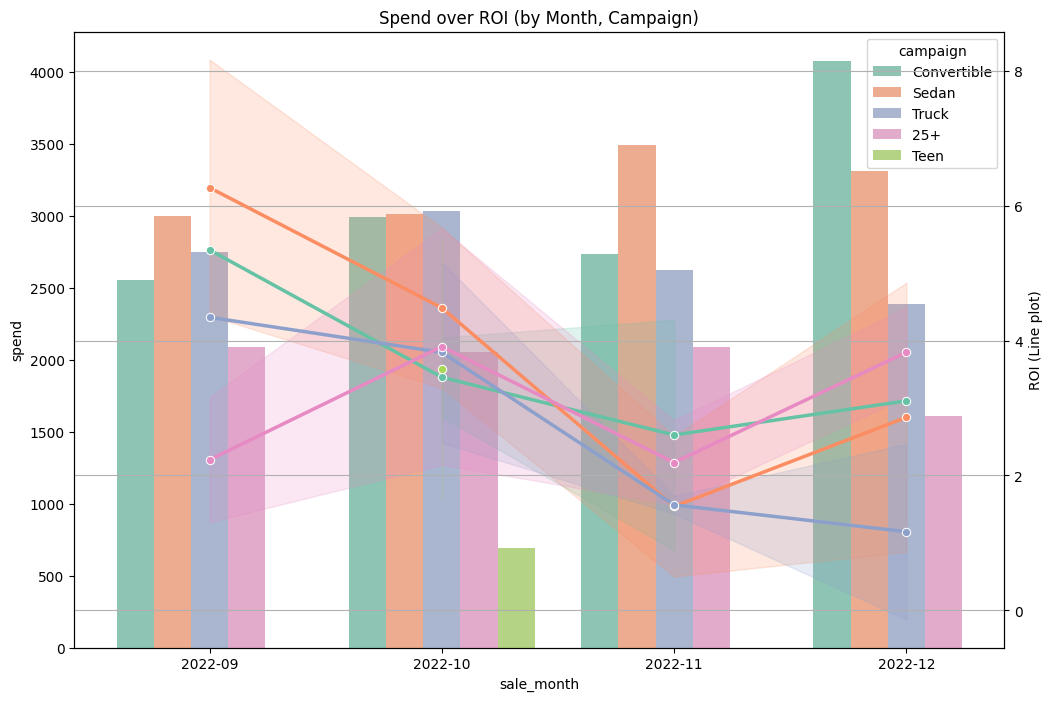

In [89]:
# Comparing spend vs ROI for each campaign
ROI_month_channel['sale_month'] = ROI_month_channel['sale_month'].astype(str)
plt.figure(figsize = (12,8))
# displaying spend over months
sns.barplot(data = ROI_month_channel, x = 'sale_month', y = 'spend', hue = 'campaign', ci = None, palette = 'Set2', alpha = 0.8)

ax2 = plt.twinx()
# displaying ROI over months
sns.lineplot(data = ROI_month_channel, x = 'sale_month', y = 'ROI', hue = 'campaign', marker = 'o', ax = ax2, legend = False, palette = 'Set2', linewidth = 2.5)

plt.xlabel('Sale Month')
plt.ylabel('Spend (Bar plot)')
ax2.set_ylabel('ROI (Line plot)')
plt.title('Spend over ROI (by Month, Campaign)')
plt.grid(True)
plt.show()

/tmp/ipykernel_224/1195728281.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data = ROI_month_channel, x = 'sale_month', y = 'spend', hue = 'campaign', ci = None, palette = 'Set2', alpha = 0.8)


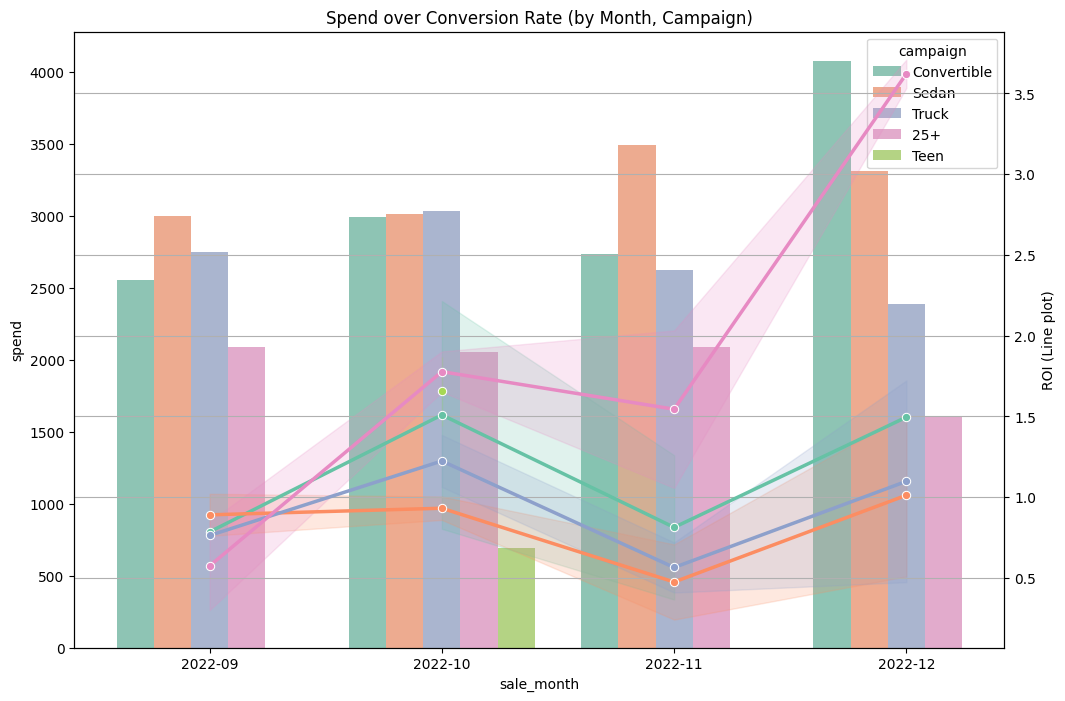

In [90]:
# Comparing spend vs Number of sales transactions for each campaign
ROI_month_channel['sale_month'] = ROI_month_channel['sale_month'].astype(str)
plt.figure(figsize = (12,8))
# displaying spend over months
sns.barplot(data = ROI_month_channel, x = 'sale_month', y = 'spend', hue = 'campaign', ci = None, palette = 'Set2', alpha = 0.8)

ax2 = plt.twinx()
# displaying ROI over months
sns.lineplot(data = ROI_month_channel, x = 'sale_month', y = 'Conversion_Rate(%)', hue = 'campaign', marker = 'o', ax = ax2, legend = False, palette = 'Set2', linewidth = 2.5)

plt.xlabel('Sale Month')
plt.ylabel('Spend (Bar plot)')
ax2.set_ylabel('ROI (Line plot)')
plt.title('Spend over Conversion Rate (by Month, Campaign)')
plt.grid(True)
plt.show()

### Recommendations (by Campaign) based on above two graphs
#### 1. Huge Potential for "25+" over "convertible" campaign - (suggested investment)


/tmp/ipykernel_224/3448923476.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data = ROI_month_channel, x = 'sale_month', y = 'spend', hue = 'category', ci = None, palette = 'Set2', alpha = 0.8)


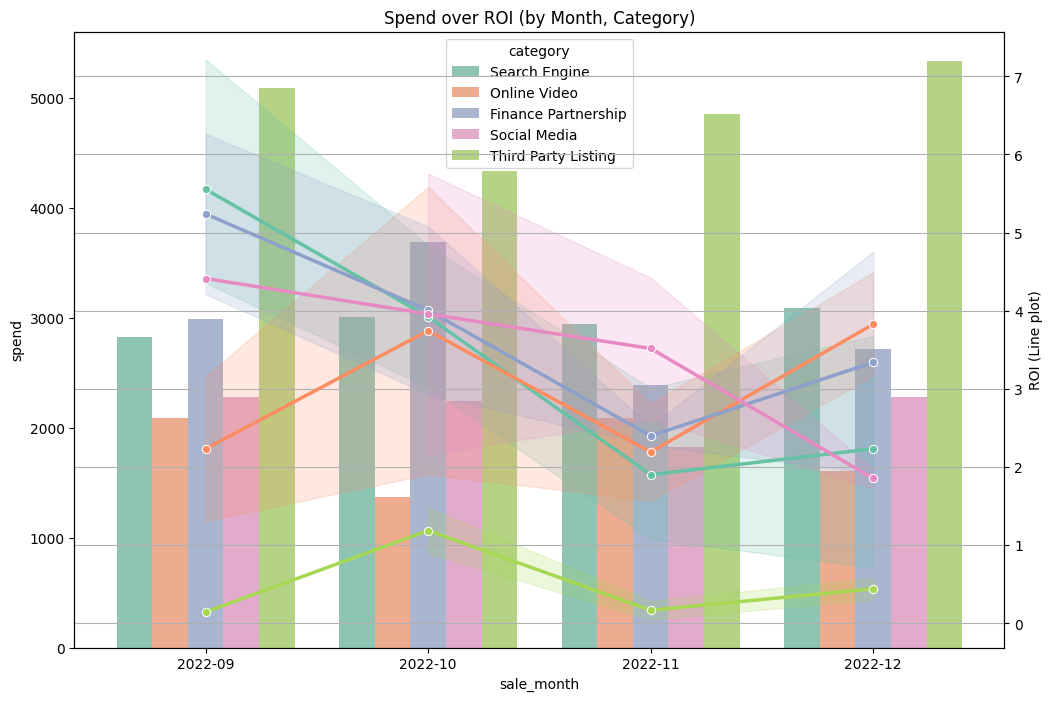

In [91]:
# Comparing spend vs ROI for each campaign
ROI_month_channel['sale_month'] = ROI_month_channel['sale_month'].astype(str)
plt.figure(figsize = (12,8))
# displaying spend over months
sns.barplot(data = ROI_month_channel, x = 'sale_month', y = 'spend', hue = 'category', ci = None, palette = 'Set2', alpha = 0.8)

ax2 = plt.twinx()
# displaying ROI over months
sns.lineplot(data = ROI_month_channel, x = 'sale_month', y = 'ROI', hue = 'category', marker = 'o', ax = ax2, legend = False, palette = 'Set2', linewidth = 2.5)

plt.xlabel('Sale Month')
plt.ylabel('Spend (Bar plot)')
ax2.set_ylabel('ROI (Line plot)')
plt.title('Spend over ROI (by Month, Category)')
plt.grid(True)
plt.show()

/tmp/ipykernel_224/2172581636.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data = ROI_month_channel, x = 'sale_month', y = 'spend', hue = 'category', ci = None, palette = 'Set2', alpha = 0.8)


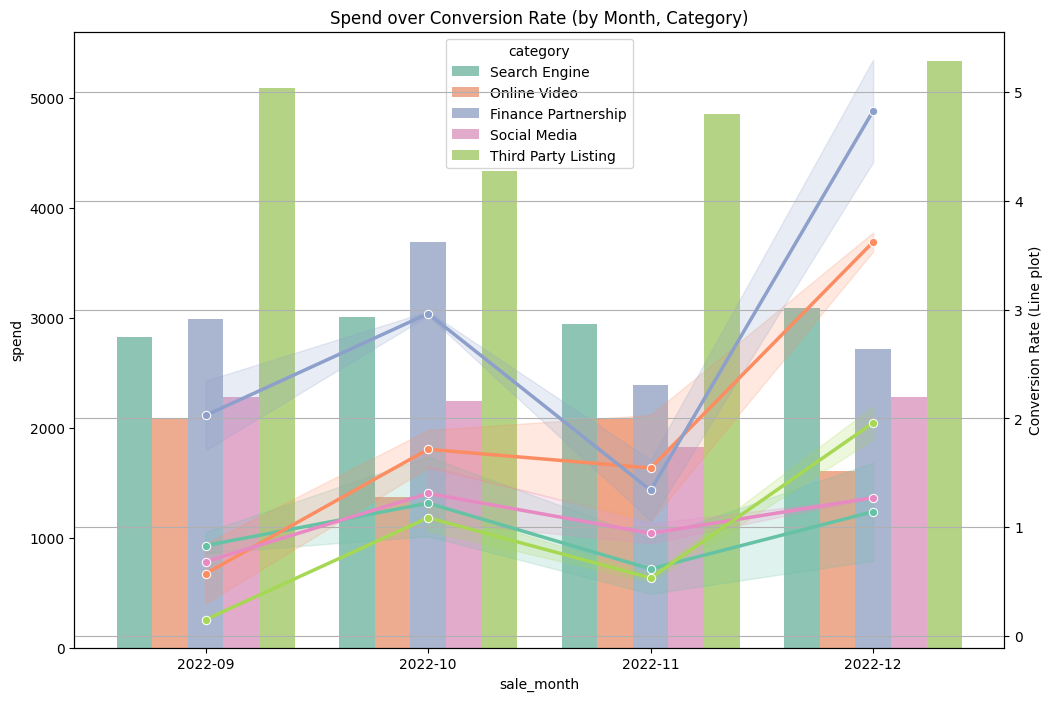

In [92]:
# Comparing spend vs Number of sales transactions for each campaign
ROI_month_channel['sale_month'] = ROI_month_channel['sale_month'].astype(str)
plt.figure(figsize = (12,8))
# displaying spend over months
sns.barplot(data = ROI_month_channel, x = 'sale_month', y = 'spend', hue = 'category', ci = None, palette = 'Set2', alpha = 0.8)

ax2 = plt.twinx()
# displaying ROI over months
sns.lineplot(data = ROI_month_channel, x = 'sale_month', y = 'Conversion_Rate(%)', hue = 'category', marker = 'o', ax = ax2, legend = False, palette = 'Set2', linewidth = 2.5)

plt.xlabel('Sale Month')
plt.ylabel('Spend (Bar plot)')
ax2.set_ylabel('Conversion Rate (Line plot)')
plt.title('Spend over Conversion Rate (by Month, Category)')
plt.grid(True)
plt.show()

### Recommendations (by Category) from the above two graphs
#### 1. "Third Party" investments can be diverted/distributed to experiment with promising "Finance Partnership" or "Online Video" advertising category. 